In [2]:
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"CUDA version: {torch.version.cuda}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    # Test GPU tensor
    x = torch.randn(3, 3).cuda()
    print(f"Tensor on: {x.device}")
else:
    print("CUDA not available. Check installation.")

PyTorch version: 2.6.0+cu124
CUDA available: True
CUDA version: 12.4
GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU
Tensor on: cuda:0


In [11]:
import os
import shutil
from pathlib import Path

def multiply_dataset(source_dir, output_dir, target_multiplier=7, min_images=7):
    """
    Simply copies original images multiple times without augmentation.
    Useful when doing online augmentation during training.
    
    Args:
        source_dir: Source dataset directory
        output_dir: Output directory for multiplied dataset
        target_multiplier: How many copies of each original image to create
        min_images: Minimum images per identity to include
    """
    source = Path(source_dir)
    output = Path(output_dir)
    skipped = 0
    total_saved = 0
    
    # Create statistics
    identity_stats = {}
    
    for identity in source.iterdir():
        if not identity.is_dir():
            continue
        
        images = list(identity.glob("*.*"))
        
        if len(images) < min_images:
            skipped += 1
            continue
        
        out_identity_dir = output / identity.name
        out_identity_dir.mkdir(parents=True, exist_ok=True)
        
        identity_total = 0
        
        for img_path in images:
            try:
                # Just copy the original image multiple times
                for copy_num in range(target_multiplier):
                    stem = img_path.stem
                    suffix = img_path.suffix
                    copy_name = f"{stem}_copy{copy_num}{suffix}"
                    shutil.copy2(img_path, out_identity_dir / copy_name)
                    total_saved += 1
                    identity_total += 1
                    
            except Exception as e:
                print(f"  Skipping {img_path.name}: {e}")
                continue
        
        identity_stats[identity.name] = {
            'original_images': len(images),
            'multiplied_images': identity_total,
            'multiplier': identity_total / len(images)
        }
    
    print(f"\n✓ Dataset Multiplication Complete!")
    print(f"  Total images saved : {total_saved}")
    print(f"  Identities skipped : {skipped} (fewer than {min_images} images)")
    print(f"\n  Average multiplier: {sum(s['multiplier'] for s in identity_stats.values()) / len(identity_stats):.1f}x")
    
    return identity_stats

# ── Usage ──────────────────────────────────────────────────────────────────────
identity_stats = multiply_dataset(
    source_dir = "C:/Users/thari/OneDrive/Desktop/Partial/casia dataset",
    output_dir = "C:/Users/thari/OneDrive/Desktop/Partial/Multiplied_Dataset",
    target_multiplier = 7,  # Create 7 copies of each original image
)

# Print sample statistics
print("\nSample identity statistics:")
for identity, stats in list(identity_stats.items())[:5]:
    print(f"  {identity}: {stats['original_images']} → {stats['multiplied_images']} images ({stats['multiplier']:.1f}x)")


✓ Dataset Multiplication Complete!
  Total images saved : 141379
  Identities skipped : 0 (fewer than 7 images)

  Average multiplier: 7.0x

Sample identity statistics:
  000001: 101 → 707 images (7.0x)
  000003: 101 → 707 images (7.0x)
  000006: 101 → 707 images (7.0x)
  000008: 101 → 707 images (7.0x)
  000009: 101 → 707 images (7.0x)


In [12]:
import os, shutil, random
from pathlib import Path

def split_dataset(source_dir, train_dir, val_dir, test_dir,
                  val_ratio=0.15, test_ratio=0.15, seed=42):
    random.seed(seed)
    source = Path(source_dir)

    skipped = 0

    for identity in source.iterdir():
        if not identity.is_dir():
            continue

        images = list(identity.glob("*.*"))

        # Need enough images to appear in all three splits meaningfully
        if len(images) < 7:
            skipped += 1
            continue

        random.shuffle(images)

        val_count  = max(1, int(len(images) * val_ratio))
        test_count = max(1, int(len(images) * test_ratio))

        val_images   = images[:val_count]
        test_images  = images[val_count : val_count + test_count]
        train_images = images[val_count + test_count:]

        for split_images, split_dir in [
            (train_images, train_dir),
            (val_images,   val_dir),
            (test_images,  test_dir),
        ]:
            for img in split_images:
                dst = Path(split_dir) / identity.name / img.name
                dst.parent.mkdir(parents=True, exist_ok=True)
                shutil.copy(img, dst)

    print(f"Split complete. Skipped {skipped} identities with fewer than 7 images.")


# Usage
split_dataset(
    source_dir = "C:/Users/thari/OneDrive/Desktop/Partial/Augmented",
    train_dir  = "C:/Users/thari/OneDrive/Desktop/Partial/split_01/train",
    val_dir    = "C:/Users/thari/OneDrive/Desktop/Partial/split_01/val",
    test_dir   = "C:/Users/thari/OneDrive/Desktop/Partial/split_01/test",
    val_ratio  = 0.15,
    test_ratio = 0.15,
)

Split complete. Skipped 0 identities with fewer than 7 images.


In [2]:

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
import torchvision.transforms as transforms
from tqdm import tqdm
import math
import os
import random

from occ import RandomFaceOcclusion

# ==================== TRAIN TRANSFORM ====================

train_transform = transforms.Compose([
    # --- Simulate partial views ---
    transforms.RandomResizedCrop(
        112,
        scale=(0.5, 1.0),
        ratio=(0.9, 1.1)
    ),

    transforms.RandomHorizontalFlip(p=0.5),

    # --- Pose variation ---
    transforms.RandomApply([
        transforms.RandomRotation(20),
    ], p=0.5),

    # --- Illumination ---
    transforms.ColorJitter(
        brightness=0.6,
        contrast=0.6,
        saturation=0.4,
        hue=0.1
    ),

    transforms.RandomGrayscale(p=0.2),

    # --- Blur ---
    transforms.RandomApply([
        transforms.GaussianBlur(kernel_size=5)
    ], p=0.3),

    transforms.ToTensor(),

    # 🔥 Structured face occlusion (NEW)
    RandomFaceOcclusion(p=0.5),

    # 🔥 Random patch occlusion (existing)
    transforms.RandomErasing(
        p=0.4,
        scale=(0.02, 0.2),
        ratio=(0.3, 3.3),
        value='random'
    ),

    transforms.Normalize([0.5]*3, [0.5]*3),
])


# ==================== VALIDATION TRANSFORM ====================

val_transform = transforms.Compose([
    transforms.Resize((112, 112)),
    transforms.CenterCrop(112),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
import torchvision.transforms as transforms
from tqdm import tqdm
import math
import os
import random

In [4]:
# ==================== MODEL ARCHITECTURE ====================
class InvertedResidual(nn.Module):
    def __init__(self, in_c, out_c, stride=1, expand=2):
        super().__init__()
        hidden = in_c * expand
        self.use_res = (stride == 1 and in_c == out_c)
        
        self.block = nn.Sequential(
            nn.Conv2d(in_c, hidden, 1, bias=False),
            nn.BatchNorm2d(hidden), nn.PReLU(hidden),
            nn.Conv2d(hidden, hidden, 3, stride=stride, padding=1, groups=hidden, bias=False),
            nn.BatchNorm2d(hidden), nn.PReLU(hidden),
            nn.Conv2d(hidden, out_c, 1, bias=False),
            nn.BatchNorm2d(out_c),
        )

    def forward(self, x):
        return x + self.block(x) if self.use_res else self.block(x)

class MobileFaceNet(nn.Module):
    def __init__(self, embedding_size=512, dropout=0.4):
        super().__init__()
        
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, 3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(64), nn.PReLU(64),
            nn.Conv2d(64, 64, 3, stride=1, padding=1, groups=64, bias=False),
            nn.BatchNorm2d(64), nn.PReLU(64),
            
            InvertedResidual(64, 64, stride=2, expand=2),
            InvertedResidual(64, 64, stride=1, expand=2),
            InvertedResidual(64, 64, stride=1, expand=2),
            InvertedResidual(64, 64, stride=1, expand=2),
            
            InvertedResidual(64, 128, stride=2, expand=2),
            InvertedResidual(128, 128, stride=1, expand=2),
            InvertedResidual(128, 128, stride=1, expand=2),
            InvertedResidual(128, 128, stride=1, expand=2),
            
            InvertedResidual(128, 128, stride=2, expand=2),
            InvertedResidual(128, 128, stride=1, expand=2),
        )
        
        self.conv_sep = nn.Sequential(
            nn.Conv2d(128, 512, 1, bias=False),
            nn.BatchNorm2d(512), nn.PReLU(512),
            nn.Conv2d(512, 512, 7, groups=512, bias=False),
            nn.BatchNorm2d(512),
        )
        
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(512, embedding_size, bias=False)
        self.bn = nn.BatchNorm1d(embedding_size)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        x = self.features(x)
        x = self.conv_sep(x)
        x = x.view(x.size(0), -1)
        x = self.dropout(x)
        x = self.fc(x)
        x = self.bn(x)
        return F.normalize(x, p=2, dim=1)

In [5]:
# ==================== ARC FACE LOSS ====================
class ArcFaceLoss(nn.Module):
    def __init__(self, num_classes, embedding_size=512, s=64.0, m=0.5):
        super().__init__()
        self.s = s
        self.m = m
        self.weight = nn.Parameter(torch.FloatTensor(num_classes, embedding_size))
        nn.init.xavier_uniform_(self.weight)
        
        self.cos_m = math.cos(m)
        self.sin_m = math.sin(m)
        self.th = math.cos(math.pi - m)
        self.mm = math.sin(math.pi - m) * m

    def forward(self, embeddings, labels):
        cosine = F.linear(embeddings, F.normalize(self.weight))
        cosine = torch.clamp(cosine, -1.0 + 1e-7, 1.0 - 1e-7)
        
        sine = torch.sqrt(1.0 - cosine**2)
        phi = cosine * self.cos_m - sine * self.sin_m
        phi = torch.where(cosine > self.th, phi, cosine - self.mm)
        
        one_hot = torch.zeros_like(cosine)
        one_hot.scatter_(1, labels.view(-1, 1), 1)
        
        output = (one_hot * phi) + ((1 - one_hot) * cosine)
        output *= self.s
        
        return F.cross_entropy(output, labels)

In [6]:
train_dir = "C:/Users/thari/OneDrive/Desktop/Partial/split/train"
val_dir = "C:/Users/thari/OneDrive/Desktop/Partial/split/val"

train_dataset = ImageFolder(train_dir, transform=train_transform)
val_dataset = ImageFolder(val_dir, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=128, num_workers=2, pin_memory=True)

num_classes = len(train_dataset.classes)

print(f"Classes: {num_classes}")

print(f"Train samples: {len(train_dataset)}")
print(f"Val samples: {len(val_dataset)}")

Classes: 200
Train samples: 226364
Val samples: 48394


In [21]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = MobileFaceNet(embedding_size=512, dropout=0.4).to(device)
criterion = ArcFaceLoss(num_classes, embedding_size=512, s=64.0, m=0.5).to(device)

# CRITICAL FIX: Separate optimizers for model and ArcFace weight
# Model optimizer with standard SGD
model_optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.1,
    momentum=0.9,
    weight_decay=5e-4,
    nesterov=True
)

# ArcFace weight optimizer with lower LR (or use Adam/SGD with lower LR)
arcface_optimizer = torch.optim.SGD(
    [criterion.weight],  # Only optimize the class centers
    lr=0.01,  # Lower learning rate for class centers
    momentum=0.9,
    weight_decay=5e-4
)

# Alternative: Use Adam for ArcFace weight
# arcface_optimizer = torch.optim.Adam([criterion.weight], lr=0.001)

# Learning rate scheduler
EPOCHS = 50
WARMUP = 5

def lr_lambda(epoch):
    if epoch < WARMUP:
        return (epoch + 1) / WARMUP
    progress = (epoch - WARMUP) / (EPOCHS - WARMUP)
    return 0.5 * (1.0 + math.cos(math.pi * progress))

model_scheduler = torch.optim.lr_scheduler.LambdaLR(model_optimizer, lr_lambda)
# Optional: different scheduler for ArcFace weight
arcface_scheduler = torch.optim.lr_scheduler.LambdaLR(arcface_optimizer, lr_lambda)

# ==================== TRAINING LOOP ====================
best_val_acc = 0.0

print("\n" + "="*50)
print("Starting Training with Fixed ArcFace Optimization")
print("="*50)

for epoch in range(EPOCHS):
    # Training
    model.train()
    train_loss = 0
    train_correct = 0
    train_total = 0
    
    for imgs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
        imgs, labels = imgs.to(device), labels.to(device)
        
        # Zero gradients for both optimizers
        model_optimizer.zero_grad()
        arcface_optimizer.zero_grad()
        
        # Forward pass
        embeddings = model(imgs)
        loss = criterion(embeddings, labels)
        
        # Backward pass
        loss.backward()
        
        # Clip gradients for model (optional)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        
        # Step both optimizers
        model_optimizer.step()
        arcface_optimizer.step()
        
        train_loss += loss.item()
        
        # Calculate accuracy
        with torch.no_grad():
            cosine = F.linear(embeddings, F.normalize(criterion.weight))
            _, pred = torch.max(cosine, 1)
            train_correct += (pred == labels).sum().item()
            train_total += labels.size(0)
    
    # Validation
    model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            embeddings = model(imgs)
            loss = criterion(embeddings, labels)
            
            val_loss += loss.item()
            
            cosine = F.linear(embeddings, F.normalize(criterion.weight))
            _, pred = torch.max(cosine, 1)
            val_correct += (pred == labels).sum().item()
            val_total += labels.size(0)
    
    # Update schedulers
    model_scheduler.step()
    arcface_scheduler.step()
    
    # Calculate metrics
    avg_train_loss = train_loss / len(train_loader)
    train_acc = train_correct / train_total
    avg_val_loss = val_loss / len(val_loader)
    val_acc = val_correct / val_total
    
    # Get current learning rates
    current_lr = model_scheduler.get_last_lr()[0]
    
    # Print results
    print(f"\nEpoch {epoch+1:02d}/{EPOCHS}")
    print(f"  Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"  Val Loss:   {avg_val_loss:.4f} | Val Acc:   {val_acc:.4f}")
    print(f"  LR: {current_lr:.6f}")
    
    # Check overfitting warning
    if train_acc - val_acc > 0.1:
        print(f"  ⚠️  Overfitting warning: Train-Val gap = {train_acc - val_acc:.4f}")
    
    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            'model_state_dict': model.state_dict(),
            'criterion_weight': criterion.weight,
            'num_classes': num_classes,
            'val_acc': val_acc,
            'epoch': epoch
        }, "best_mobilefacenet.pth")
        print(f"  ✓ Best model saved! (Val Acc: {val_acc:.4f})")
    
    print("-" * 50)

# Save final model
torch.save({
    'model_state_dict': model.state_dict(),
    'criterion_weight': criterion.weight,
    'num_classes': num_classes
}, "mobilefacenet_final.pth")

print("\n" + "="*50)
print(f"✅ Training Completed!")
print(f"Best Validation Accuracy: {best_val_acc:.4f}")
print("="*50)


Starting Training with Fixed ArcFace Optimization


Epoch 1/50: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1769/1769 [09:40<00:00,  3.05it/s]



Epoch 01/50
  Train Loss: 26.2369 | Train Acc: 0.0132
  Val Loss:   20.3341 | Val Acc:   0.0267
  LR: 0.040000
  ✓ Best model saved! (Val Acc: 0.0267)
--------------------------------------------------


Epoch 2/50: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1769/1769 [09:37<00:00,  3.07it/s]



Epoch 02/50
  Train Loss: 20.5308 | Train Acc: 0.0196
  Val Loss:   20.4841 | Val Acc:   0.0225
  LR: 0.060000
--------------------------------------------------


...


Epoch 48/50
  Train Loss: 16.1587 | Train Acc: 0.6626
  Val Loss:   16.4505 | Val Acc:   0.8342
  LR: 0.000487
  ✓ Best model saved! (Val Acc: 0.8342)
--------------------------------------------------


Epoch 49/50: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1769/1769 [09:45<00:00,  3.02it/s]



Epoch 49/50
  Train Loss: 16.1103 | Train Acc: 0.6727
  Val Loss:   16.4478 | Val Acc:   0.8408
  LR: 0.000122
  ✓ Best model saved! (Val Acc: 0.8408)
--------------------------------------------------


Epoch 50/50: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1769/1769 [08:44<00:00,  3.37it/s]



Epoch 50/50
  Train Loss: 16.0916 | Train Acc: 0.6763
  Val Loss:   16.4343 | Val Acc:   0.8440
  LR: 0.000000
  ✓ Best model saved! (Val Acc: 0.8440)
--------------------------------------------------

✅ Training Completed!
Best Validation Accuracy: 0.8440


In [24]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [15]:
pip install seaborn matplotlib

Note: you may need to restart the kernel to use updated packages.


Device: cuda

📦 Loading model...
✓ Model loaded from best_mobilefacenet.pth
  Best validation accuracy: 0.8440

==============🔍 STARTING EVALUATION===============

VERIFICATION TEST (1:1 Matching)
Positive pairs: 400, Negative pairs: 400


Testing: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 800/800 [00:18<00:00, 43.22it/s]



📊 Results:
  Threshold: 0.960
  Accuracy: 0.9463 (94.62%)
  TPR (Recall): 0.9400
  FPR: 0.0475
  AUC-ROC: 0.9833


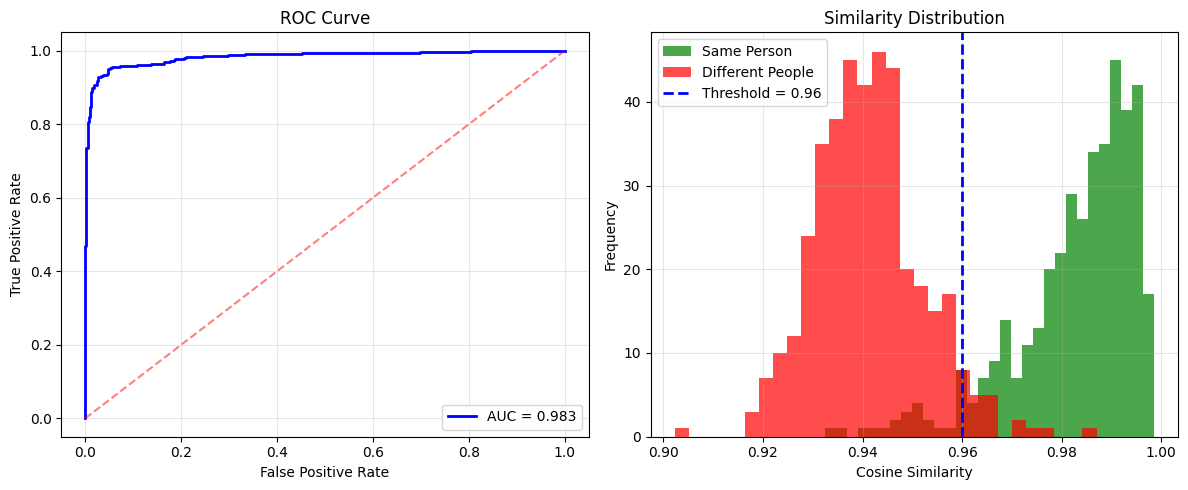


IDENTIFICATION TEST (1:N Matching)


Extracting embeddings: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 379/379 [00:43<00:00,  8.81it/s]


Total samples: 48394
Number of classes: 200


Testing identification: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████| 48394/48394 [42:52<00:00, 18.81it/s]



📊 Results:
  Top-1 Accuracy: 0.9665 (96.65%)
  Top-5 Accuracy: 0.9850 (98.50%)


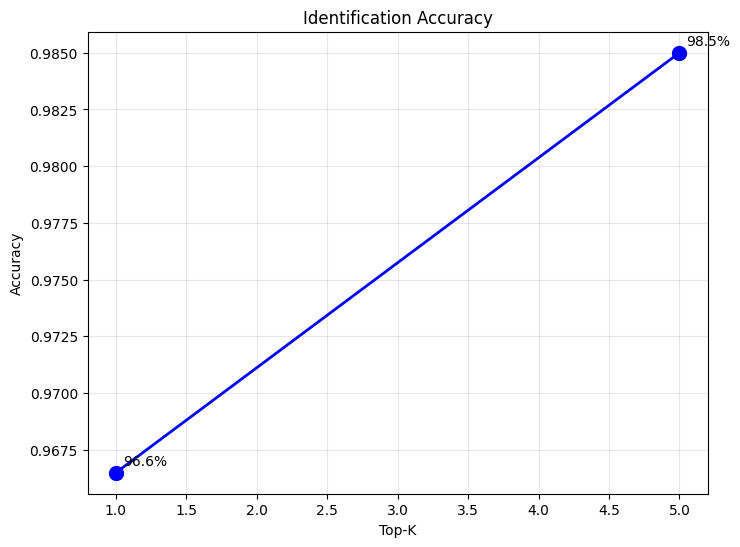


EMBEDDING VISUALIZATION
Running t-SNE on 300 samples...


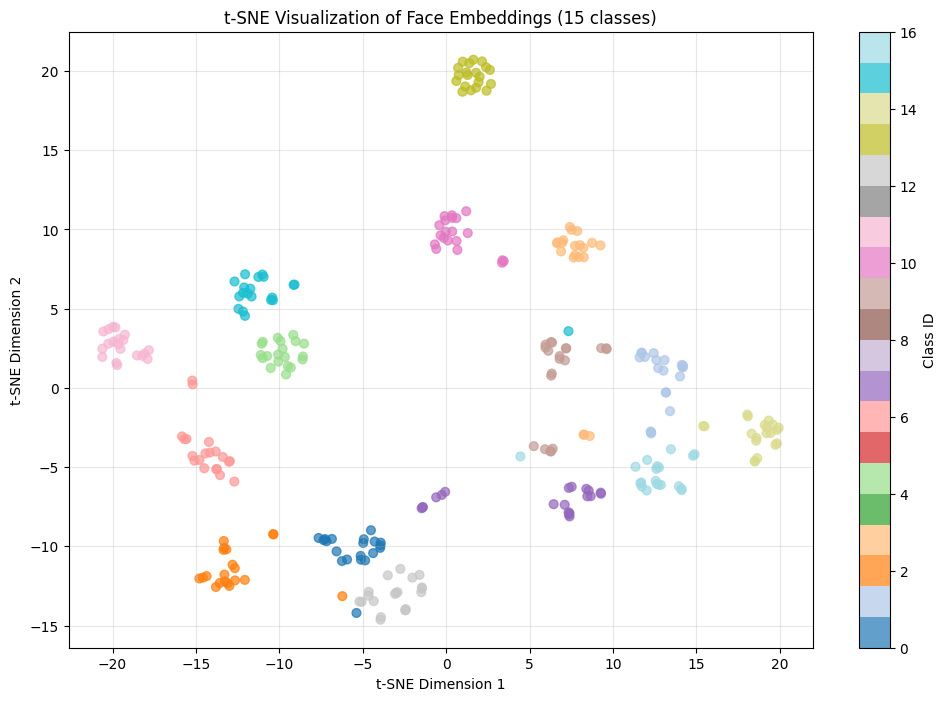

✓ Visualized 300 samples from 15 classes

===============📊 EVALUATION SUMMARY===============
Verification Accuracy: 94.62%
ROC-AUC Score: 0.9833
Identification Top-1: 96.65%
Identification Top-5: 98.50%

✅ Evaluation completed!


In [13]:
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
from torchvision import transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, roc_curve, auc, confusion_matrix
from sklearn.manifold import TSNE
from tqdm import tqdm
import os
import random

# ==================== SETUP ====================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# ==================== VALIDATION TRANSFORM ====================
val_transform = transforms.Compose([
    transforms.Resize((112, 112)),
    transforms.CenterCrop(112),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

# ==================== LOAD MODEL ====================
def load_model(model_path, model_class, embedding_size=512, dropout=0.4):
    """Load trained model"""
    model = model_class(embedding_size=embedding_size, dropout=dropout).to(device)
    
    checkpoint = torch.load(model_path, map_location=device)
    
    if 'model_state_dict' in checkpoint:
        model.load_state_dict(checkpoint['model_state_dict'])
        print(f"✓ Model loaded from {model_path}")
        if 'val_acc' in checkpoint:
            print(f"  Best accuracy: {checkpoint['val_acc']:.4f}")
    else:
        model.load_state_dict(checkpoint)
        print(f"✓ Model loaded from {model_path}")
    
    model.eval()
    return model

# ==================== HELPER FUNCTIONS ====================
def get_embeddings(model, dataloader):
    """Extract all embeddings and labels"""
    embeddings = []
    labels = []
    
    with torch.no_grad():
        for images, lbls in tqdm(dataloader, desc="Extracting embeddings"):
            images = images.to(device)
            emb = model(images)
            embeddings.append(emb.cpu().numpy())
            labels.append(lbls.numpy())
    
    return np.vstack(embeddings), np.concatenate(labels)

# ==================== 1. VERIFICATION TEST ====================
def test_verification(model, val_dir, num_pairs=500):
    """Test 1:1 face verification"""
    print("\n" + "="*50)
    print("VERIFICATION TEST (1:1 Matching)")
    print("="*50)
    
    # Collect images by class
    class_images = {}
    for class_name in os.listdir(val_dir):
        class_path = os.path.join(val_dir, class_name)
        if os.path.isdir(class_path):
            images = [os.path.join(class_path, f) for f in os.listdir(class_path) 
                     if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
            if len(images) >= 2:
                class_images[class_name] = images
    
    if len(class_images) < 2:
        print("Not enough images for verification test")
        return None, None
    
    # Create pairs
    pos_pairs, neg_pairs = [], []
    
    # Positive pairs (same person)
    for class_name, images in class_images.items():
        n = min(len(images)//2, max(1, num_pairs//len(class_images)))
        for _ in range(n):
            img1, img2 = random.sample(images, 2)
            pos_pairs.append((img1, img2))
    
    # Negative pairs (different people)
    class_names = list(class_images.keys())
    for _ in range(len(pos_pairs)):
        c1, c2 = random.sample(class_names, 2)
        neg_pairs.append((random.choice(class_images[c1]), random.choice(class_images[c2])))
    
    pairs = pos_pairs + neg_pairs
    labels = [1]*len(pos_pairs) + [0]*len(neg_pairs)
    
    print(f"Positive pairs: {len(pos_pairs)}, Negative pairs: {len(neg_pairs)}")
    
    # Compute similarities
    similarities = []
    transform = val_transform
    
    for img1, img2 in tqdm(pairs, desc="Testing"):
        # Load and process images
        img1_tensor = transform(Image.open(img1).convert('RGB')).unsqueeze(0).to(device)
        img2_tensor = transform(Image.open(img2).convert('RGB')).unsqueeze(0).to(device)
        
        with torch.no_grad():
            emb1 = model(img1_tensor).cpu().numpy()[0]
            emb2 = model(img2_tensor).cpu().numpy()[0]
        
        # Cosine similarity
        sim = np.dot(emb1, emb2) / (np.linalg.norm(emb1) * np.linalg.norm(emb2))
        similarities.append(sim)
    
    # Find best threshold
    similarities = np.array(similarities)
    labels = np.array(labels)
    
    best_thresh, best_acc = 0.5, 0
    for thresh in np.arange(0.1, 0.97, 0.01):
        acc = accuracy_score(labels, similarities > thresh)
        if acc > best_acc:
            best_acc = acc
            best_thresh = thresh
    
    # Results
    pred = similarities > best_thresh
    tn, fp, fn, tp = confusion_matrix(labels, pred).ravel()
    
    print(f"\n📊 Results:")
    print(f"  Threshold: {best_thresh:.3f}")
    print(f"  Accuracy: {best_acc:.4f} ({best_acc*100:.2f}%)")
    print(f"  TPR (Recall): {tp/(tp+fn):.4f}")
    print(f"  FPR: {fp/(fp+tn):.4f}")
    
    # ROC
    fpr, tpr, _ = roc_curve(labels, similarities)
    roc_auc = auc(fpr, tpr)
    print(f"  AUC-ROC: {roc_auc:.4f}")
    
    # Plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    ax1.plot(fpr, tpr, 'b-', linewidth=2, label=f'AUC = {roc_auc:.3f}')
    ax1.plot([0,1], [0,1], 'r--', alpha=0.5)
    ax1.set_xlabel('False Positive Rate')
    ax1.set_ylabel('True Positive Rate')
    ax1.set_title('ROC Curve')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    ax2.hist(similarities[labels==1], bins=30, alpha=0.7, label='Same Person', color='green')
    ax2.hist(similarities[labels==0], bins=30, alpha=0.7, label='Different People', color='red')
    ax2.axvline(best_thresh, color='blue', linestyle='--', linewidth=2, 
                label=f'Threshold = {best_thresh:.2f}')
    ax2.set_xlabel('Cosine Similarity')
    ax2.set_ylabel('Frequency')
    ax2.set_title('Similarity Distribution')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return best_acc, roc_auc

# ==================== 2. IDENTIFICATION TEST ====================
def test_identification(model, val_dir, top_k=[1, 5]):
    """Test 1:N face identification"""
    print("\n" + "="*50)
    print("IDENTIFICATION TEST (1:N Matching)")
    print("="*50)
    
    # Create dataset and dataloader
    dataset = ImageFolder(val_dir, transform=val_transform)
    loader = DataLoader(dataset, batch_size=128, shuffle=False, num_workers=2)
    
    # Get all embeddings
    embeddings, labels = get_embeddings(model, loader)
    n = len(embeddings)
    
    print(f"Total samples: {n}")
    print(f"Number of classes: {len(np.unique(labels))}")
    
    # Test each sample
    correct = {k: 0 for k in top_k}
    
    for i in tqdm(range(n), desc="Testing identification"):
        query = embeddings[i]
        query_label = labels[i]
        
        # Compute cosine similarities
        sim = np.dot(embeddings, query) / (np.linalg.norm(embeddings, axis=1) * np.linalg.norm(query))
        sim[i] = -1  # Exclude self
        
        # Get top-k predictions
        top_indices = np.argsort(sim)[::-1]
        
        for k in top_k:
            if query_label in labels[top_indices[:k]]:
                correct[k] += 1
    
    # Results
    print(f"\n📊 Results:")
    for k in top_k:
        acc = correct[k] / n
        print(f"  Top-{k} Accuracy: {acc:.4f} ({acc*100:.2f}%)")
    
    # Plot
    plt.figure(figsize=(8, 6))
    accuracies = [correct[k]/n for k in top_k]
    plt.plot(top_k, accuracies, 'bo-', linewidth=2, markersize=10)
    plt.xlabel('Top-K')
    plt.ylabel('Accuracy')
    plt.title('Identification Accuracy')
    plt.grid(True, alpha=0.3)
    for k, acc in zip(top_k, accuracies):
        plt.annotate(f'{acc*100:.1f}%', (k, acc), xytext=(5, 5), textcoords='offset points')
    plt.show()
    
    return {k: correct[k]/n for k in top_k}

# ==================== 3. EMBEDDING VISUALIZATION ====================
def visualize_embeddings(model, val_dir, max_classes=15, max_samples_per_class=20):
    """Visualize embeddings using t-SNE"""
    print("\n" + "="*50)
    print("EMBEDDING VISUALIZATION")
    print("="*50)
    
    # Load dataset
    dataset = ImageFolder(val_dir, transform=val_transform)
    
    # Select top classes (with most samples)
    class_counts = {}
    for idx, (_, label) in enumerate(dataset.samples):
        class_counts[label] = class_counts.get(label, 0) + 1
    
    sorted_classes = sorted(class_counts.items(), key=lambda x: x[1], reverse=True)
    selected_classes = [c[0] for c in sorted_classes[:max_classes]]
    
    # Collect samples
    embeddings, labels = [], []
    class_sample_count = {c: 0 for c in selected_classes}
    
    for img, label in dataset:
        if label in selected_classes and class_sample_count[label] < max_samples_per_class:
            with torch.no_grad():
                emb = model(img.unsqueeze(0).to(device)).cpu().numpy()[0]
            embeddings.append(emb)
            labels.append(label)
            class_sample_count[label] += 1
    
    embeddings = np.array(embeddings)
    labels = np.array(labels)
    
    # t-SNE
    print(f"Running t-SNE on {len(embeddings)} samples...")
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    embeddings_2d = tsne.fit_transform(embeddings)
    
    # Plot
    plt.figure(figsize=(12, 8))
    scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], 
                         c=labels, cmap='tab20', alpha=0.7, s=40)
    plt.colorbar(scatter, label='Class ID')
    plt.title(f't-SNE Visualization of Face Embeddings ({len(set(labels))} classes)')
    plt.xlabel('t-SNE Dimension 1')
    plt.ylabel('t-SNE Dimension 2')
    plt.grid(True, alpha=0.3)
    plt.show()
    
    print(f"✓ Visualized {len(embeddings)} samples from {len(set(labels))} classes")

# ==================== MAIN ====================
def main():
    """Main evaluation function"""
    
    # Paths - UPDATE THESE
    model_path = "best_mobilefacenet.pth"
    val_dir = "C:/Users/thari/OneDrive/Desktop/Partial/split/val"
    
    # Check paths
    if not os.path.exists(model_path):
        print(f"❌ Model not found: {model_path}")
        print("Please update model_path variable")
        return
    
    if not os.path.exists(val_dir):
        print(f"❌ Validation directory not found: {val_dir}")
        print("Please update val_dir variable")
        return
    
    # Import your model class from the training cell
    # Since you're in a Jupyter notebook, the classes are already defined in memory
    # You don't need to import them - just use them directly
    
    print("\n📦 Loading model...")
    
    # Create model instance (using the class defined in your previous cell)
    model = MobileFaceNet(embedding_size=512, dropout=0.4).to(device)
    
    # Load weights
    checkpoint = torch.load(model_path, map_location=device)
    if 'model_state_dict' in checkpoint:
        model.load_state_dict(checkpoint['model_state_dict'])
        print(f"✓ Model loaded from {model_path}")
        if 'val_acc' in checkpoint:
            print(f"  Best validation accuracy: {checkpoint['val_acc']:.4f}")
    else:
        model.load_state_dict(checkpoint)
        print(f"✓ Model loaded from {model_path}")
    
    model.eval()
    
    # Run evaluations
    print("\n" + "🔍 STARTING EVALUATION".center(50, "="))
    
    # 1. Verification Test
    ver_acc, roc_auc = test_verification(model, val_dir, num_pairs=500)
    
    # 2. Identification Test
    id_results = test_identification(model, val_dir, top_k=[1, 5])
    
    # 3. Embedding Visualization
    visualize_embeddings(model, val_dir, max_classes=15, max_samples_per_class=20)
    
    # Summary
    print("\n" + "📊 EVALUATION SUMMARY".center(50, "="))
    if ver_acc:
        print(f"Verification Accuracy: {ver_acc*100:.2f}%")
        print(f"ROC-AUC Score: {roc_auc:.4f}")
    print(f"Identification Top-1: {id_results[1]*100:.2f}%")
    print(f"Identification Top-5: {id_results[5]*100:.2f}%")
    print("\n✅ Evaluation completed!")

# Run the evaluation
if __name__ == "__main__":
    main()

In [11]:
import torch
import torch.nn.functional as F
from torchvision import transforms
from PIL import Image
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([
    transforms.Resize((112, 112)),
    transforms.CenterCrop(112),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

def load_model(model_path):
    model = MobileFaceNet(embedding_size=512, dropout=0.4).to(device)
    checkpoint = torch.load(model_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    return model

model = load_model("best_mobilefacenet.pth")

def get_embedding(image_path):
    img = Image.open(image_path).convert('RGB')
    img = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        emb = model(img)

    return emb.cpu().numpy()[0]


def cosine_similarity(emb1, emb2):
    return np.dot(emb1, emb2) / (
        np.linalg.norm(emb1) * np.linalg.norm(emb2)
    )

full_face_path = "C:/Users/thari/OneDrive/Pictures/Camera Roll/WIN_20260417_00_17_39_Pro.jpg"
full_embedding = get_embedding(full_face_path)

print("✅ Full face enrolled.")

partial_faces = [
    "C:/Users/thari/OneDrive/Pictures/Camera Roll/WIN_20260417_00_18_01_Pro.jpg", 
    "C:/Users/thari/OneDrive/Pictures/Camera Roll/WIN_20260417_00_26_37_Pro.jpg", 
    "C:/Users/thari/OneDrive/Pictures/Camera Roll/WIN_20260417_00_29_45_Pro.jpg", 
    "C:/Users/thari/OneDrive/Pictures/WIN_20260417_00_17_39_Pro.jpg", 
    "C:/Users/thari/Downloads/WhatsApp Image 2026-04-17 at 12.01.06 AM.jpeg"
]

THRESHOLD = 0.96   # Replace with your best_thresh if available

results = []

for i, img_path in enumerate(partial_faces):
    test_embedding = get_embedding(img_path)
    similarity = cosine_similarity(full_embedding, test_embedding)

    match = similarity > THRESHOLD

    results.append((img_path, similarity, match))

    print(f"\nTest {i+1}: {img_path}")
    print(f"  Similarity: {similarity:.4f}")
    print(f"  Result: {'✅ SAME PERSON' if match else '❌ DIFFERENT PERSON'}")

print("\n" + "="*40)
print("FINAL RESULTS")
print("="*40)

for img_path, sim, match in results:
    print(f"{img_path:15} | {sim:.4f} | {'MATCH' if match else 'NO MATCH'}")

✅ Full face enrolled.

Test 1: C:/Users/thari/OneDrive/Pictures/Camera Roll/WIN_20260417_00_18_01_Pro.jpg
  Similarity: 0.9778
  Result: ✅ SAME PERSON

Test 2: C:/Users/thari/OneDrive/Pictures/Camera Roll/WIN_20260417_00_26_37_Pro.jpg
  Similarity: 0.9632
  Result: ✅ SAME PERSON

Test 3: C:/Users/thari/OneDrive/Pictures/Camera Roll/WIN_20260417_00_29_45_Pro.jpg
  Similarity: 0.9640
  Result: ✅ SAME PERSON

Test 4: C:/Users/thari/OneDrive/Pictures/WIN_20260417_00_17_39_Pro.jpg
  Similarity: 0.9857
  Result: ✅ SAME PERSON

Test 5: C:/Users/thari/Downloads/WhatsApp Image 2026-04-17 at 12.01.06 AM.jpeg
  Similarity: 0.9445
  Result: ❌ DIFFERENT PERSON

FINAL RESULTS
C:/Users/thari/OneDrive/Pictures/Camera Roll/WIN_20260417_00_18_01_Pro.jpg | 0.9778 | MATCH
C:/Users/thari/OneDrive/Pictures/Camera Roll/WIN_20260417_00_26_37_Pro.jpg | 0.9632 | MATCH
C:/Users/thari/OneDrive/Pictures/Camera Roll/WIN_20260417_00_29_45_Pro.jpg | 0.9640 | MATCH
C:/Users/thari/OneDrive/Pictures/WIN_20260417_00_17_3

C:\Users\thari\AppData\Local\Temp\ipykernel_48336\2209375864.py:34: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\thari\AppData\Local\Temp\ipykernel_48336\2209375864.py:34: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


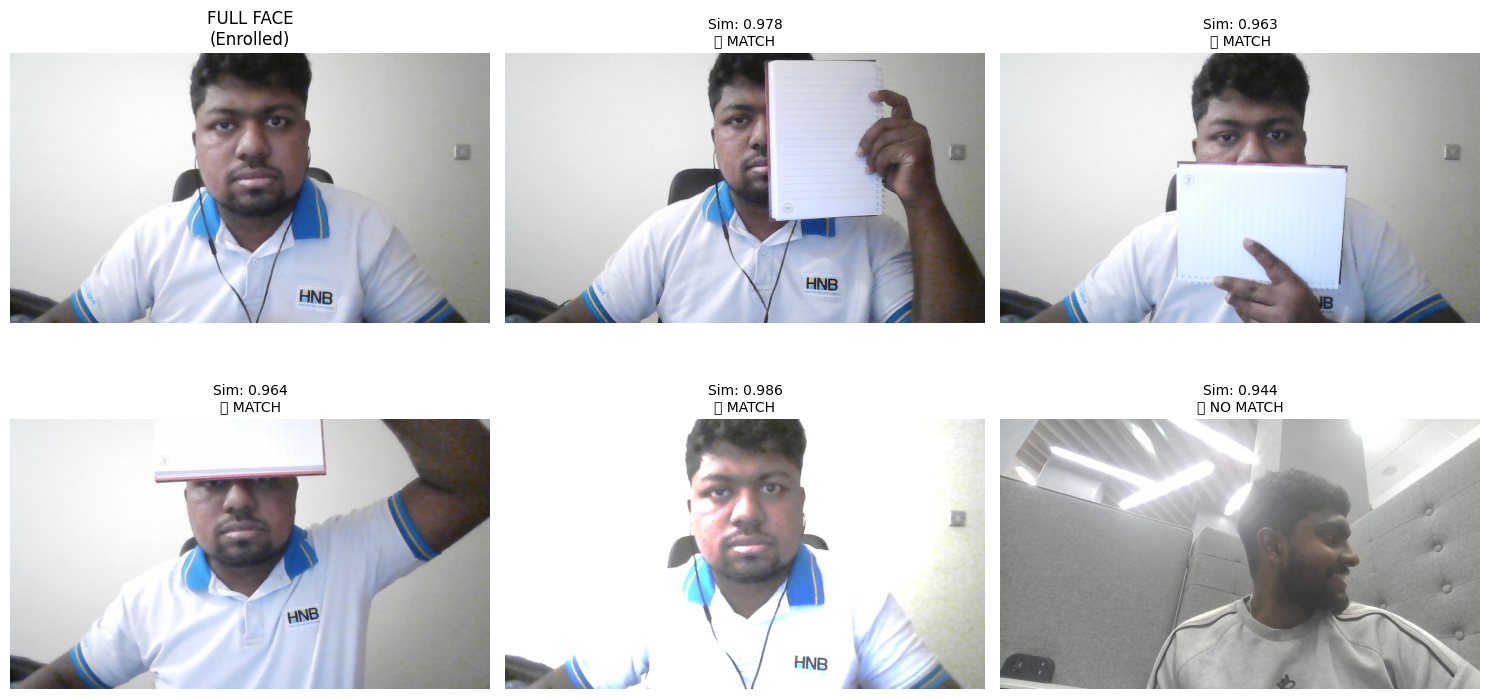

In [12]:
import matplotlib.pyplot as plt

# ==================== VISUALIZATION ====================

plt.figure(figsize=(15, 8))

# --- Show full face ---
full_img = Image.open(full_face_path).convert("RGB")
plt.subplot(2, 3, 1)
plt.imshow(full_img)
plt.title("FULL FACE\n(Enrolled)", fontsize=12)
plt.axis("off")

# --- Show partial faces with results ---
for i, (img_path, sim, match) in enumerate(results):
    img = Image.open(img_path).convert("RGB")

    plt.subplot(2, 3, i + 2)
    plt.imshow(img)

    title = f"Sim: {sim:.3f}\n"
    title += "✅ MATCH" if match else "❌ NO MATCH"

    plt.title(title, fontsize=10)
    plt.axis("off")

    # 🔥 Add colored border
    ax = plt.gca()
    color = 'green' if match else 'red'
    for spine in ax.spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(3)

plt.tight_layout()
plt.show()